In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
img = cv2.imread('/content/Fig0304(a)(breast_digital_Xray).tif', cv2.IMREAD_UNCHANGED)

print("Image shape:", img.shape)
print("Data type:", img.dtype)


Image shape: (571, 482)
Data type: uint8


In [ ]:
# Find maximum intensity value based on data type
L = np.max(img)

print("Maximum intensity value:", L)


Maximum intensity value: 255


In [ ]:
negative_img = L - img


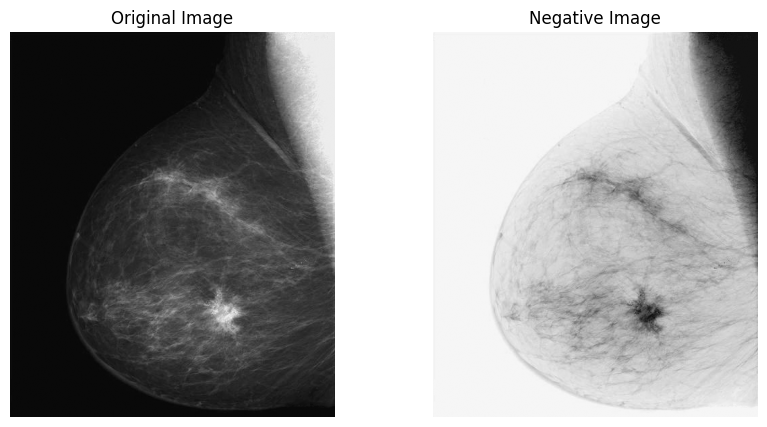

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Negative Image")
plt.imshow(negative_img, cmap='gray')
plt.axis('off')

plt.show()


In [ ]:
img = cv2.imread('/content/Fig0305(a)(DFT_no_log).tif', cv2.IMREAD_UNCHANGED)

print("Shape:", img.shape)
print("Data type:", img.dtype)


Shape: (256, 256)
Data type: uint8


In [ ]:

img_norm = img / np.max(img)

In [ ]:
# Log transformation
log_img = np.log(1 + img_norm)


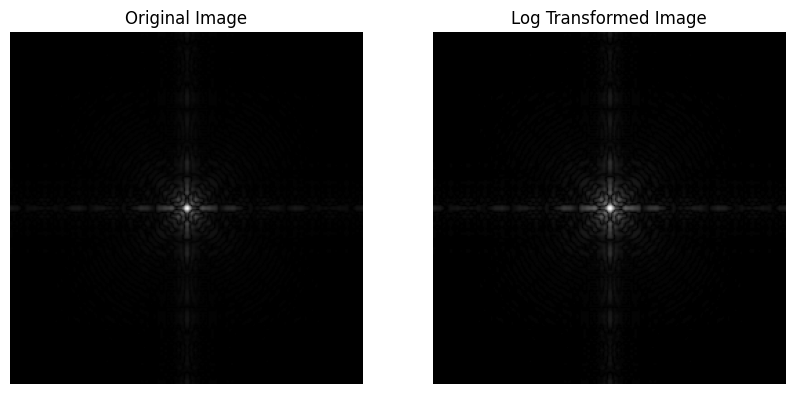

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Log Transformed Image")
plt.imshow(log_img, cmap='gray')
plt.axis('off')

plt.show()


In [ ]:
img = cv2.imread('/content/Fig0307(a)(intensity_ramp).tif', cv2.IMREAD_GRAYSCALE)
# Convert to float and normalize to [0,1]
img_norm = img.astype(np.float32) / 255.0

gamma_display = 2.5
img_gamma_25 = img_norm ** gamma_display

gamma_correction = 1 / gamma_display
img_gamma_corrected = img_norm ** gamma_correction

img_final_display = img_gamma_corrected ** gamma_display

def to_uint8(image):
    image = np.clip(image, 0, 1)
    return (image * 255).astype(np.uint8)

img_gamma_25_u8 = to_uint8(img_gamma_25)
img_gamma_corrected_u8 = to_uint8(img_gamma_corrected)
img_final_display_u8 = to_uint8(img_final_display)




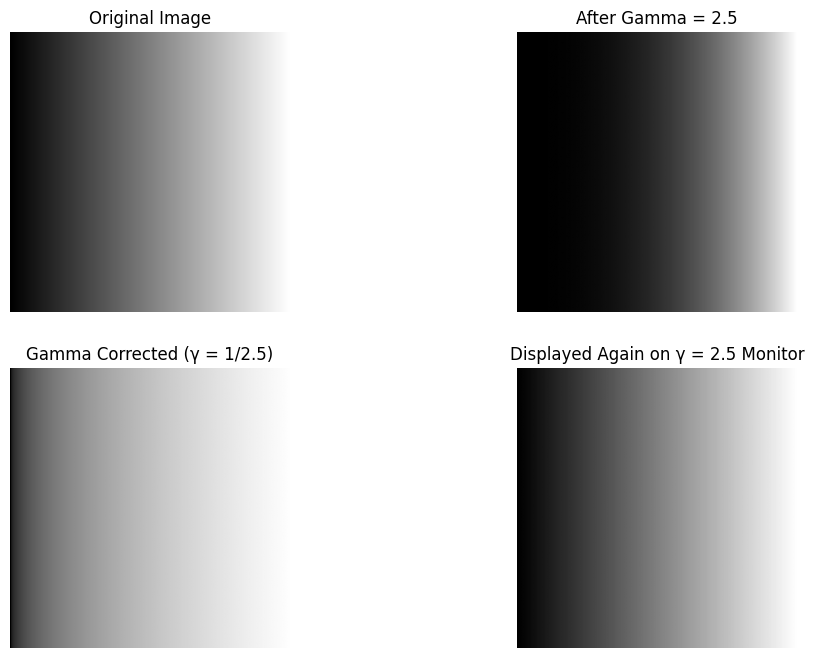

In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title("After Gamma = 2.5")
plt.imshow(img_gamma_25_u8, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title("Gamma Corrected (γ = 1/2.5)")
plt.imshow(img_gamma_corrected_u8, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title("Displayed Again on γ = 2.5 Monitor")
plt.imshow(img_final_display_u8, cmap='gray')
plt.axis('off')

plt.show()


In [ ]:
# Read image
img = cv2.imread('/content/Fig0308(a)(fractured_spine).tif', cv2.IMREAD_GRAYSCALE)

# Normalize to [0,1]
img_norm = img.astype(np.float32) / 255.0

In [ ]:
gamma_06 = img_norm ** 0.6
gamma_04 = img_norm ** 0.4
gamma_03 = img_norm ** 0.3


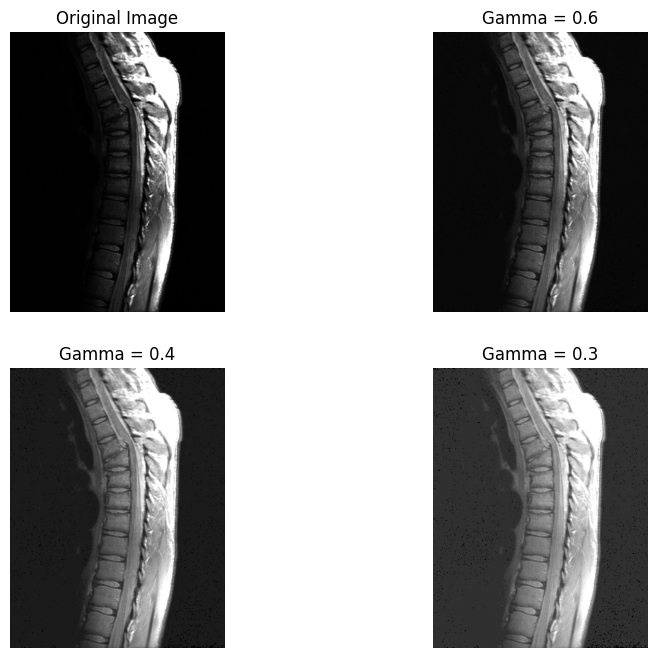

In [ ]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.title("Original Image")
plt.imshow(img_norm, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title("Gamma = 0.6")
plt.imshow(gamma_06, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title("Gamma = 0.4")
plt.imshow(gamma_04, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title("Gamma = 0.3")
plt.imshow(gamma_03, cmap='gray')
plt.axis('off')

plt.show()


In [ ]:
img = cv2.imread('/content/Fig0309(a)(washed_out_aerial_image).tif', cv2.IMREAD_GRAYSCALE)

# Normalize to [0,1]
img_norm = img.astype(np.float32) / 255.0

In [ ]:
gamma_3 = img_norm ** 3
gamma_4 = img_norm ** 4
gamma_5 = img_norm ** 5


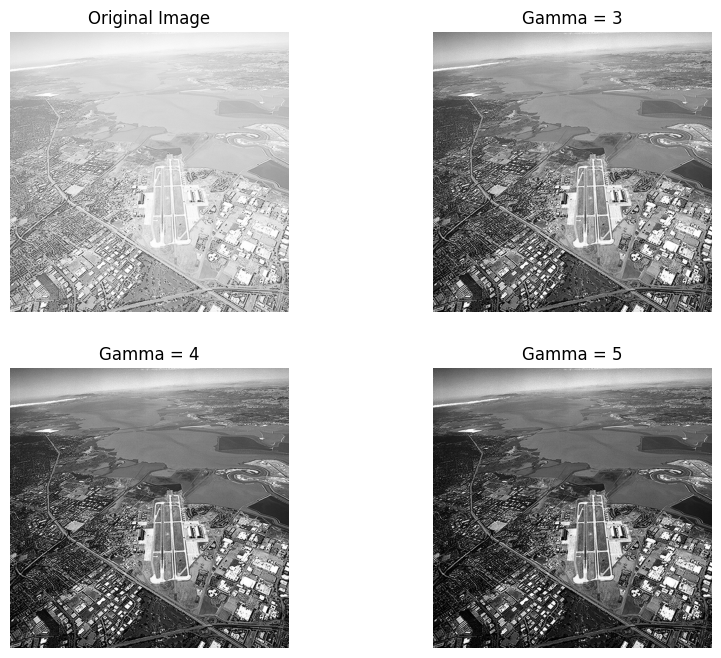

In [ ]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.title("Original Image")
plt.imshow(img_norm, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title("Gamma = 3")
plt.imshow(gamma_3, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title("Gamma = 4")
plt.imshow(gamma_4, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title("Gamma = 5")
plt.imshow(gamma_5, cmap='gray')
plt.axis('off')

plt.show()


In [ ]:
# Read image
img = cv2.imread('/content/Fig0310(b)(washed_out_pollen_image).tif', cv2.IMREAD_GRAYSCALE)



img_f = img.astype(np.float32)

L = 256

r_min = img_f.min()
r_max = img_f.max()


scenario1 = (img_f - r_min) * (L - 1) / (r_max - r_min)
scenario1 = np.clip(scenario1, 0, L-1).astype(np.uint8)


In [ ]:
mean = img_f.mean()
std  = img_f.std()

k = 0.5   # controls width of mid-range
r1 = mean - k * std
r2 = mean + k * std


scenario2 = np.zeros_like(img_f)

for i in range(img_f.shape[0]):
    for j in range(img_f.shape[1]):
        r = img_f[i, j]
        if r <= r1:
            scenario2[i, j] = 0
        elif r >= r2:
            scenario2[i, j] = L - 1
        else:
            scenario2[i, j] = (r - r1) * (L - 1) / (r2 - r1)

scenario2 = scenario2.astype(np.uint8)


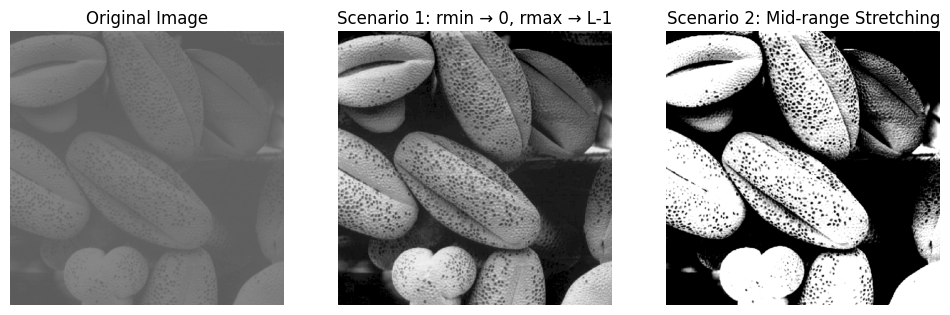

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Scenario 1: rmin → 0, rmax → L-1")
plt.imshow(scenario1, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Scenario 2: Mid-range Stretching")
plt.imshow(scenario2, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.show()



In [ ]:
img = cv2.imread('/content/Fig0312(a)(kidney).tif', cv2.IMREAD_GRAYSCALE)
img_f = img.astype(np.float32)

L = 256

In [ ]:
# Select intensity range
A = 150
B = 255

slice_case1 = np.zeros_like(img)

slice_case1[(img >= A) & (img <= B)] = L - 1


In [ ]:
slice_case2 = img.copy()

slice_case2[(img >= A) & (img <= B)] = L - 1
slice_case2[(img < A) | (img > B)] = (0.4 * img[(img < A) | (img > B)]).astype(np.uint8)


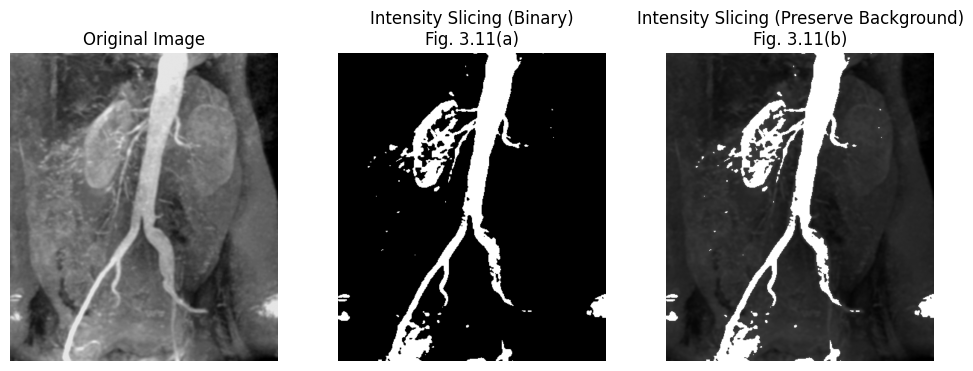

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Intensity Slicing (Binary)\nFig. 3.11(a)")
plt.imshow(slice_case1, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Intensity Slicing (Preserve Background)\nFig. 3.11(b)")
plt.imshow(slice_case2, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.show()


In [ ]:


# Read image (grayscale)
img = cv2.imread('/content/Fig0314(a)(100-dollars).tif', cv2.IMREAD_GRAYSCALE)

# Sanity check
print(img.dtype, img.min(), img.max())


uint8 0 247


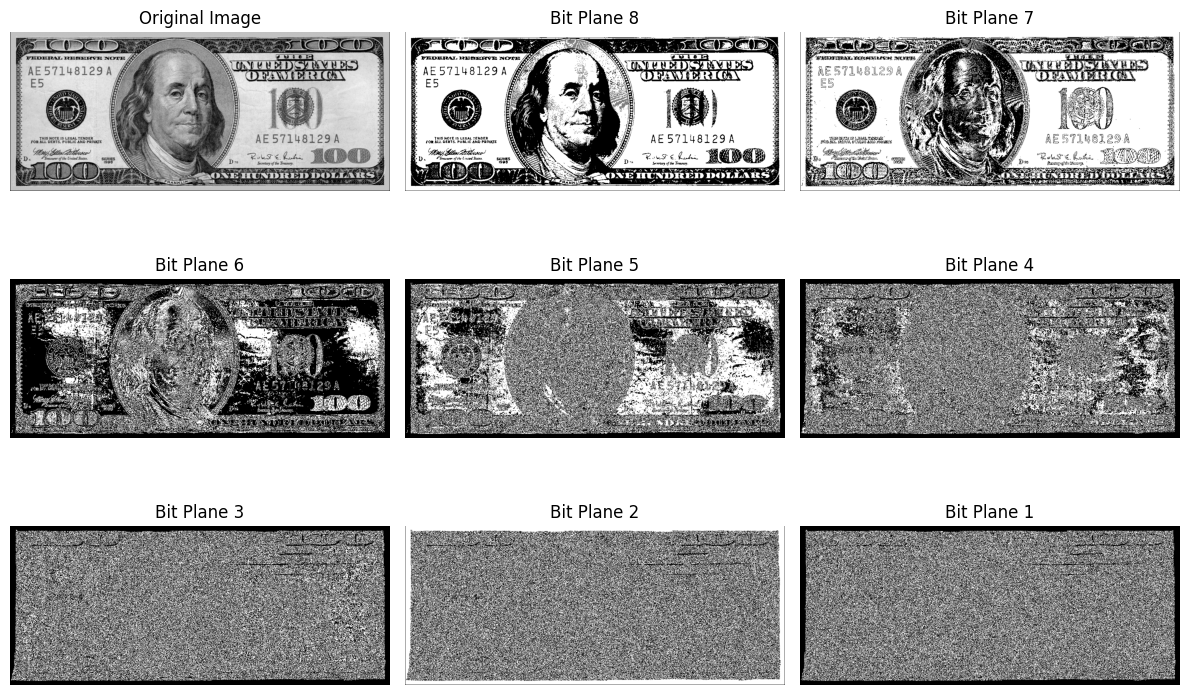

In [ ]:
bit_planes = []

for k in range(8):  # k = 0 (LSB) to 7 (MSB)
    plane = (img >> k) & 1
    bit_planes.append(plane)

plt.figure(figsize=(12, 8))

# (a) Original image
plt.subplot(3, 3, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

# (b) to (i): Bit planes 8 → 1
for i in range(8):
    plt.subplot(3, 3, i + 2)
    plt.title(f"Bit Plane {8 - i}")
    plt.imshow(bit_planes[7 - i] * 255, cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
rec_87 = bit_planes[7]*128 + bit_planes[6]*64
rec_876 = rec_87 + bit_planes[5]*32
rec_8765 = rec_876 + bit_planes[4]*16


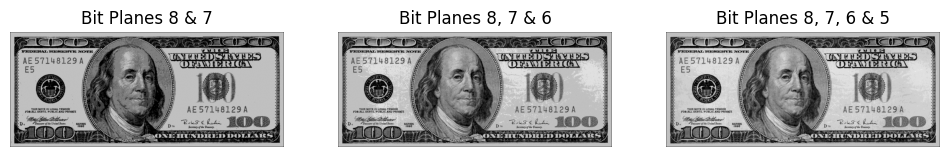

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Bit Planes 8 & 7")
plt.imshow(rec_87, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Bit Planes 8, 7 & 6")
plt.imshow(rec_876, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Bit Planes 8, 7, 6 & 5")
plt.imshow(rec_8765, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.show()


# Implementation of Histogram Processing (Section 3.3)


In [ ]:
# Read images (grayscale)
img1 = cv2.imread('/content/Fig0316(1)(top_left).tif', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('/content/Fig0316(2)(2nd_from_top).tif', cv2.IMREAD_GRAYSCALE)
img3 = cv2.imread('/content/Fig0316(3)(third_from_top).tif', cv2.IMREAD_GRAYSCALE)
img4 = cv2.imread('/content/Fig0316(4)(bottom_left).tif', cv2.IMREAD_GRAYSCALE)

In [ ]:
def normalized_histogram(img):
    hist = np.zeros(256)
    M, N = img.shape
    total_pixels = M * N

    for r in range(256):
        hist[r] = np.sum(img == r)

    return hist / total_pixels   # probability p(r_k)


In [ ]:
h1 = normalized_histogram(img1)
h2 = normalized_histogram(img2)
h3 = normalized_histogram(img3)
h4 = normalized_histogram(img4)

rk = np.arange(256)


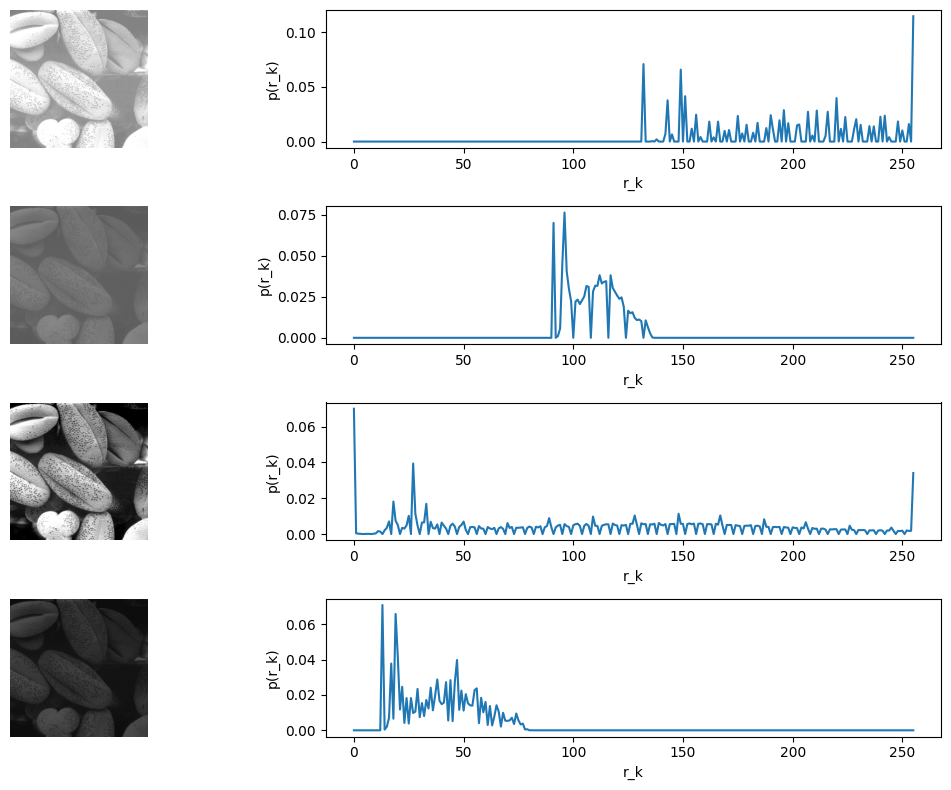

In [ ]:
plt.figure(figsize=(12, 8))

# ---- Dark image ----
plt.subplot(4, 2, 1)
plt.imshow(img1, cmap='gray', vmin=0, vmax=255)

plt.axis('off')

plt.subplot(4, 2, 2)
plt.plot(rk, h1)

plt.xlabel("r_k")
plt.ylabel("p(r_k)")

# ---- Light image ----
plt.subplot(4, 2, 3)
plt.imshow(img2, cmap='gray', vmin=0, vmax=255)

plt.axis('off')

plt.subplot(4, 2, 4)
plt.plot(rk, h2)

plt.xlabel("r_k")
plt.ylabel("p(r_k)")

# ---- Low-contrast image ----
plt.subplot(4, 2, 5)
plt.imshow(img3, cmap='gray', vmin=0, vmax=255)

plt.axis('off')

plt.subplot(4, 2, 6)
plt.plot(rk, h3)

plt.xlabel("r_k")
plt.ylabel("p(r_k)")

# ---- High-contrast image ----
plt.subplot(4, 2, 7)
plt.imshow(img4, cmap='gray', vmin=0, vmax=255)

plt.axis('off')

plt.subplot(4, 2, 8)
plt.plot(rk, h4)

plt.xlabel("r_k")
plt.ylabel("p(r_k)")

plt.tight_layout()
plt.show()


In [ ]:
# Load original images (grayscale)
img_dark  = cv2.imread('/content/Fig0320(4)(bottom_left).tif', cv2.IMREAD_GRAYSCALE)
img_light = cv2.imread('/content/Fig0320(1)(top_left).tif', cv2.IMREAD_GRAYSCALE)
img_low   = cv2.imread('/content/Fig0320(2)(2nd_from_top).tif', cv2.IMREAD_GRAYSCALE)
img_high  = cv2.imread('/content/Fig0320(3)(third_from_top).tif', cv2.IMREAD_GRAYSCALE)

moon_img = cv2.imread('/content/Fig0323(a)(mars_moon_phobos).tif', cv2.IMREAD_GRAYSCALE)

images = [img_dark, img_light, img_low, img_high]
titles = ["Dark", "Light", "Low Contrast", "High Contrast"]
L = 256
rk = np.arange(L)

In [ ]:
def manual_histogram_equalization(img):
    # Step 1: Histogram n_k
    hist = np.zeros(L)
    for r in range(L):
        hist[r] = np.sum(img == r)

    # Step 2: Normalized histogram p(r_k)
    total_pixels = img.size
    p_rk = hist / total_pixels

    # Step 3: CDF
    cdf = np.cumsum(p_rk)

    # Step 4: Transformation function
    T = np.round((L - 1) * cdf).astype(np.uint8)

    # Step 5: Apply transformation
    eq_img = np.zeros_like(img)
    for r in range(L):
        eq_img[img == r] = T[r]

    # Histogram of equalized image (normalized)
    hist_eq = np.zeros(L)
    for r in range(L):
        hist_eq[r] = np.sum(eq_img == r)

    p_eq = hist_eq / total_pixels

    return eq_img, p_eq


In [ ]:
equalized_images = []
equalized_hists = []

for img in images:
    eq_img, p_eq = manual_histogram_equalization(img)
    equalized_images.append(eq_img)
    equalized_hists.append(p_eq)


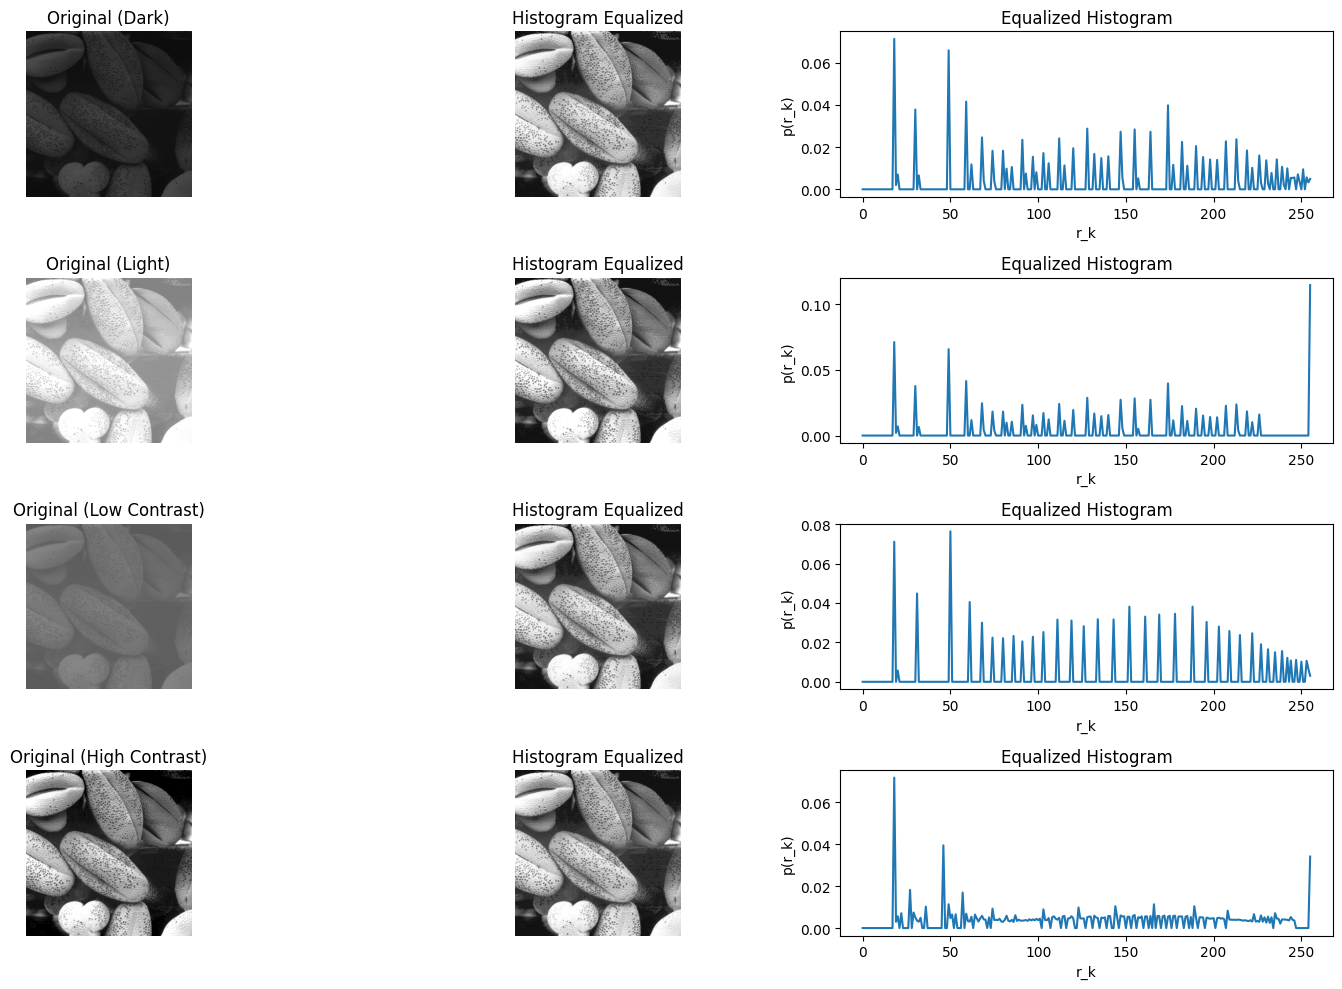

In [ ]:
plt.figure(figsize=(15, 10))

for i in range(4):
    # Original image
    plt.subplot(4, 3, 3*i + 1)
    plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
    plt.title(f"Original ({titles[i]})")
    plt.axis('off')

    # Equalized image
    plt.subplot(4, 3, 3*i + 2)
    plt.imshow(equalized_images[i], cmap='gray', vmin=0, vmax=255)
    plt.title("Histogram Equalized")
    plt.axis('off')

    # Histogram of equalized image
    plt.subplot(4, 3, 3*i + 3)
    plt.plot(rk, equalized_hists[i])
    plt.title("Equalized Histogram")
    plt.xlabel("r_k")
    plt.ylabel("p(r_k)")

plt.tight_layout()
plt.show()


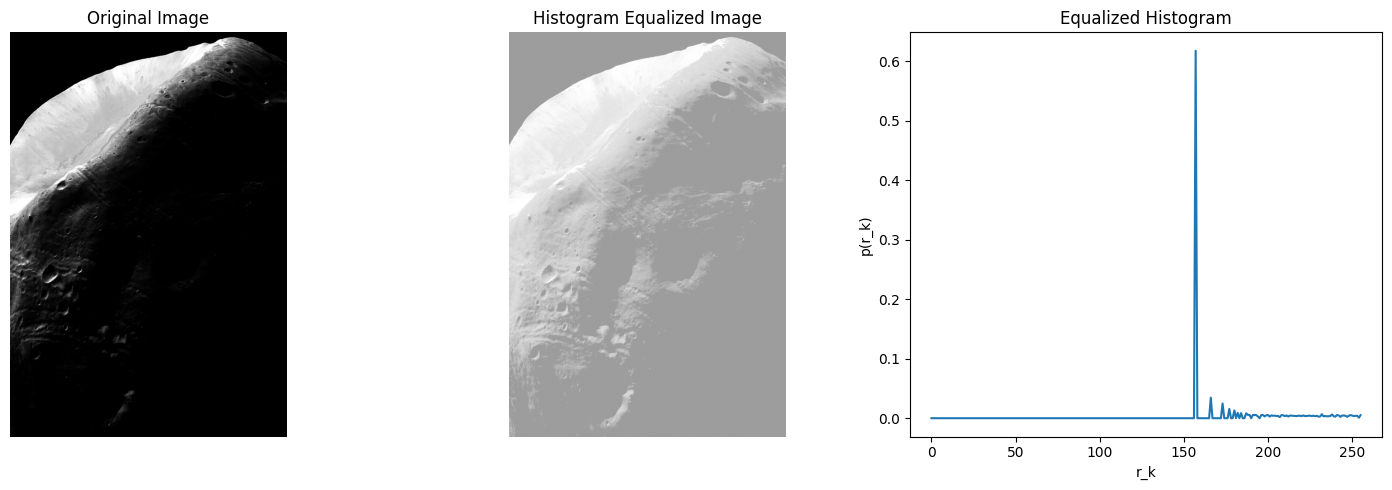

In [ ]:
eq_img, p_eq = manual_histogram_equalization(moon_img);

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(moon_img, cmap='gray', vmin=0, vmax=255)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(eq_img, cmap='gray', vmin=0, vmax=255)
plt.title("Histogram Equalized Image")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.plot(rk, p_eq)
plt.title("Equalized Histogram")
plt.xlabel("r_k")
plt.ylabel("p(r_k)")

plt.tight_layout()
plt.show()

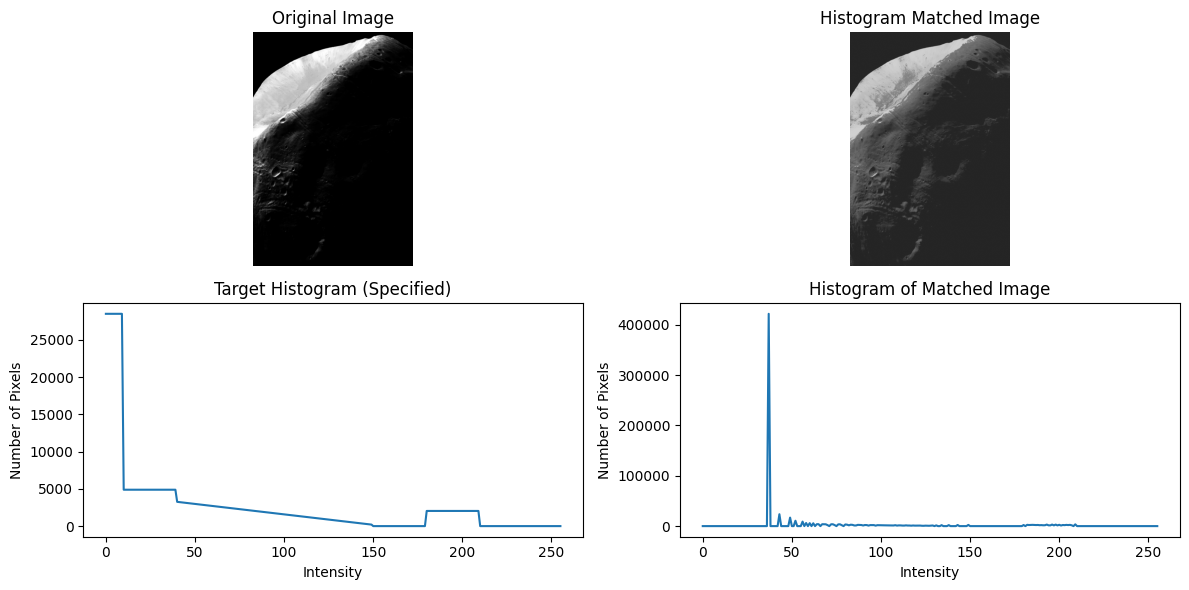

In [ ]:
img = cv2.imread('/content/Fig0323(a)(mars_moon_phobos).tif', cv2.IMREAD_GRAYSCALE)

L = 256
rk = np.arange(L)
total_pixels = img.size

src_hist_counts = np.zeros(L)
for r in range(L):
    src_hist_counts[r] = np.sum(img == r)

src_hist_prob = src_hist_counts / total_pixels
src_cdf = np.cumsum(src_hist_prob)

target_hist_shape = np.zeros(L)

target_hist_shape[0:10] = 7000
target_hist_shape[10:40] = 1200

target_hist_shape[40:150] = np.linspace(800, 50, 110)

target_hist_shape[180:210] = 500

target_hist_prob = target_hist_shape / np.sum(target_hist_shape)
target_hist_counts = target_hist_prob * total_pixels

target_cdf = np.cumsum(target_hist_prob)


mapping = np.zeros(L, dtype=np.uint8)

for r in range(L):
    diff = np.abs(src_cdf[r] - target_cdf)
    mapping[r] = np.argmin(diff)

matched_img = np.zeros_like(img)
for r in range(L):
    matched_img[img == r] = mapping[r]

matched_hist_counts = np.zeros(L)
for r in range(L):
    matched_hist_counts[r] = np.sum(matched_img == r)

plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title("Histogram Matched Image")
plt.imshow(matched_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title("Target Histogram (Specified)")
plt.plot(rk, target_hist_counts)
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")

plt.subplot(2, 2, 4)
plt.title("Histogram of Matched Image")
plt.plot(rk, matched_hist_counts)
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")

plt.tight_layout()
plt.show()

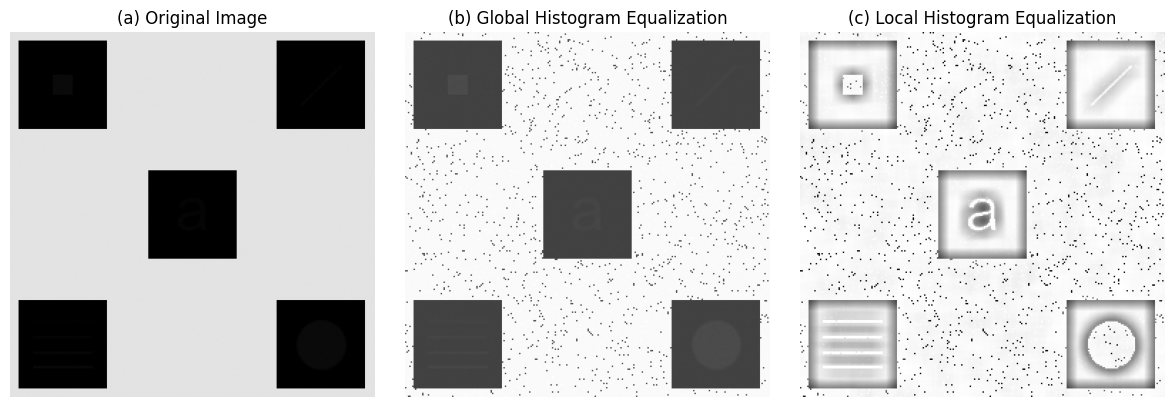

In [ ]:
img = cv2.imread('/content/Fig0326(a)(embedded_square_noisy_512).tif', cv2.IMREAD_GRAYSCALE)

L = 256

hist = np.zeros(L)
for r in range(L):
    hist[r] = np.sum(img == r)

pdf = hist / img.size
cdf = np.cumsum(pdf)

T = np.round((L - 1) * cdf).astype(np.uint8)

global_eq = np.zeros_like(img)
for r in range(L):
    global_eq[img == r] = T[r]

window_size = 31
pad = window_size // 2

padded = np.pad(img, pad, mode='reflect')
local_eq = np.zeros_like(img)

for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        window = padded[i:i+window_size, j:j+window_size]

        local_hist, _ = np.histogram(window.flatten(), bins=L, range=(0, L))

        local_pdf = local_hist / window.size
        local_cdf = np.cumsum(local_pdf)

        local_eq[i, j] = np.round((L - 1) * local_cdf[img[i, j]])

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("(a) Original Image")
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("(b) Global Histogram Equalization")
plt.imshow(global_eq, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("(c) Local Histogram Equalization")
plt.imshow(local_eq, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.tight_layout()
plt.show()

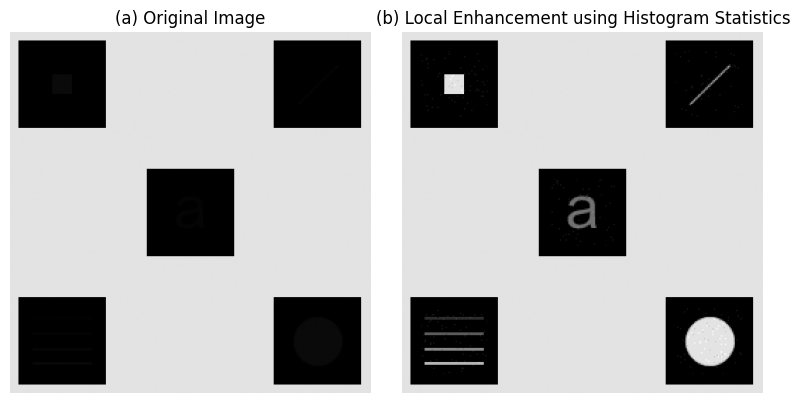

In [ ]:
# Let's start by converting our image to a float type for calculations
img = img.astype(np.float32)

# Grab the image dimensions and set the max intensity level
M, N = img.shape
L = 256

# Calculate the global mean and standard deviation of the image
# We'll use these as a reference for local enhancement decisions
mG = np.mean(img)
sG = np.std(img)

# These are parameters that control how the enhancement behaves
# They define thresholds for local mean and standard deviation
C  = 22.8 # This is our enhancement constant
k0 = 0.0
k1 = 0.1
k2 = 0.0
k3 = 0.1

# Define the size of our local processing window and calculate padding needed
window_size = 31
pad = window_size // 2

# Pad the image to handle pixels at the edges properly
padded = np.pad(img, pad, mode='reflect')

# Create an empty array to store our enhanced image
enhanced = np.zeros_like(img)

# Now, let's iterate through each pixel of the image to apply local enhancement
for x in range(M):
    for y in range(N):
        # Extract the local neighborhood (window) around the current pixel
        Sxy = padded[x:x+window_size, y:y+window_size]

        # Calculate the mean and standard deviation for this local window
        mS = np.mean(Sxy)
        sS = np.std(Sxy)

        # Check if the local statistics meet our enhancement criteria
        # If they do, apply the enhancement; otherwise, keep the original pixel value
        if (k0*mG <= mS <= k1*mG) and (k2*sG <= sS <= k3*sG):
            enhanced[x, y] = C * img[x, y]
        else:
            enhanced[x, y] = img[x, y]

# After processing, clip the enhanced values to ensure they are within a valid intensity range (0-255)
# Then convert back to an unsigned 8-bit integer format for display
enhanced = np.clip(enhanced, 0, 255).astype(np.uint8)

# Finally, let's visualize the results!
plt.figure(figsize=(8,4))

# Display the original image first
plt.subplot(1,2,1)
plt.title("(a) Original Image")
plt.imshow(img.astype(np.uint8), cmap='gray', vmin=0, vmax=255)
plt.axis('off')

# Then, show our locally enhanced image
plt.subplot(1,2,2)
plt.title("(b) Local Enhancement using Histogram Statistics")
plt.imshow(enhanced, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

# Make sure everything fits nicely and show the plot
plt.tight_layout()
plt.show()

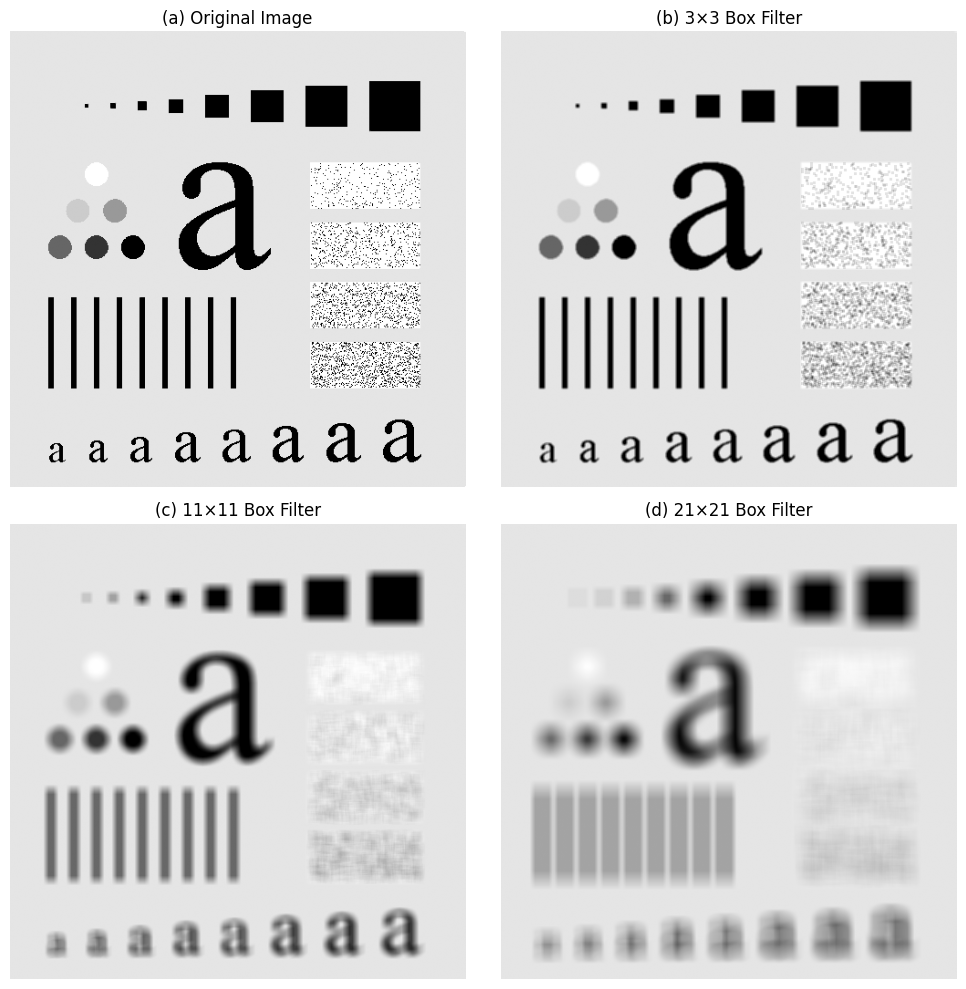

In [ ]:


# read original image
img = cv2.imread('/content/Fig0333(a)(test_pattern_blurring_orig).tif', cv2.IMREAD_GRAYSCALE)

# function for box filtering
def box_filter(image, k):
    kernel = np.ones((k, k), np.float32) / (k * k)
    return cv2.filter2D(image, -1, kernel)

# apply filters
img_3  = box_filter(img, 3)
img_11 = box_filter(img, 11)
img_21 = box_filter(img, 21)

# display results
plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.title("(a) Original Image")
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title("(b) 3×3 Box Filter")
plt.imshow(img_3, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title("(c) 11×11 Box Filter")
plt.imshow(img_11, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title("(d) 21×21 Box Filter")
plt.imshow(img_21, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.tight_layout()
plt.show()


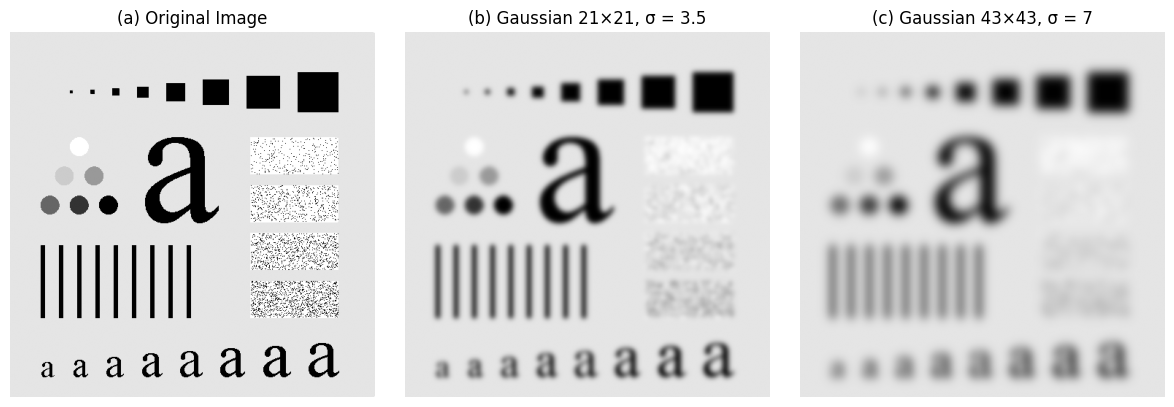

In [ ]:
# Gaussian lowpass filters
gauss_21 = cv2.GaussianBlur(img, (21, 21), sigmaX=3.5, sigmaY=3.5)
gauss_43 = cv2.GaussianBlur(img, (43, 43), sigmaX=7, sigmaY=7)

# display results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("(a) Original Image")
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("(b) Gaussian 21×21, σ = 3.5")
plt.imshow(gauss_21, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("(c) Gaussian 43×43, σ = 7")
plt.imshow(gauss_43, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.tight_layout()
plt.show()

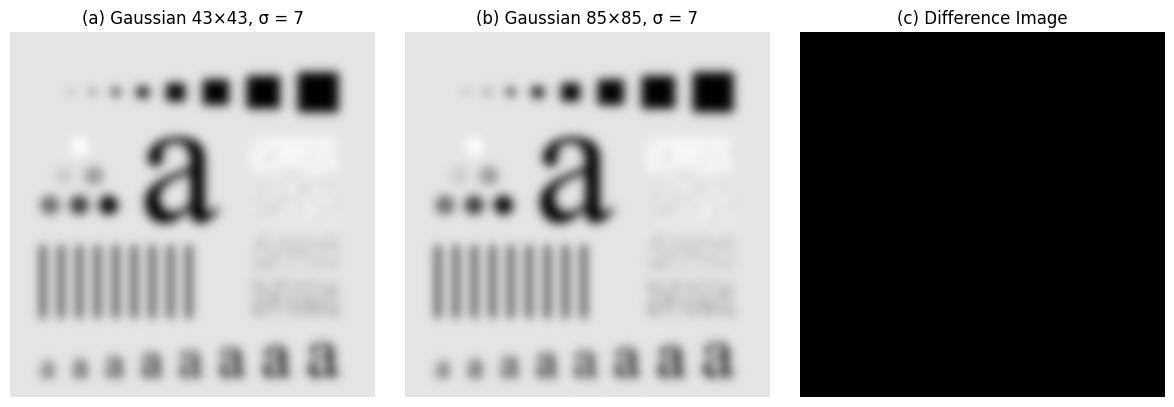

In [ ]:


# Gaussian filters with same sigma
gauss_43 = cv2.GaussianBlur(img, (43, 43), sigmaX=7, sigmaY=7)
gauss_85 = cv2.GaussianBlur(img, (85, 85), sigmaX=7, sigmaY=7)

# difference image
diff = cv2.absdiff(gauss_43, gauss_85)

# display results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("(a) Gaussian 43×43, σ = 7")
plt.imshow(gauss_43, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("(b) Gaussian 85×85, σ = 7")
plt.imshow(gauss_85, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("(c) Difference Image")
plt.imshow(diff, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.tight_layout()
plt.show()


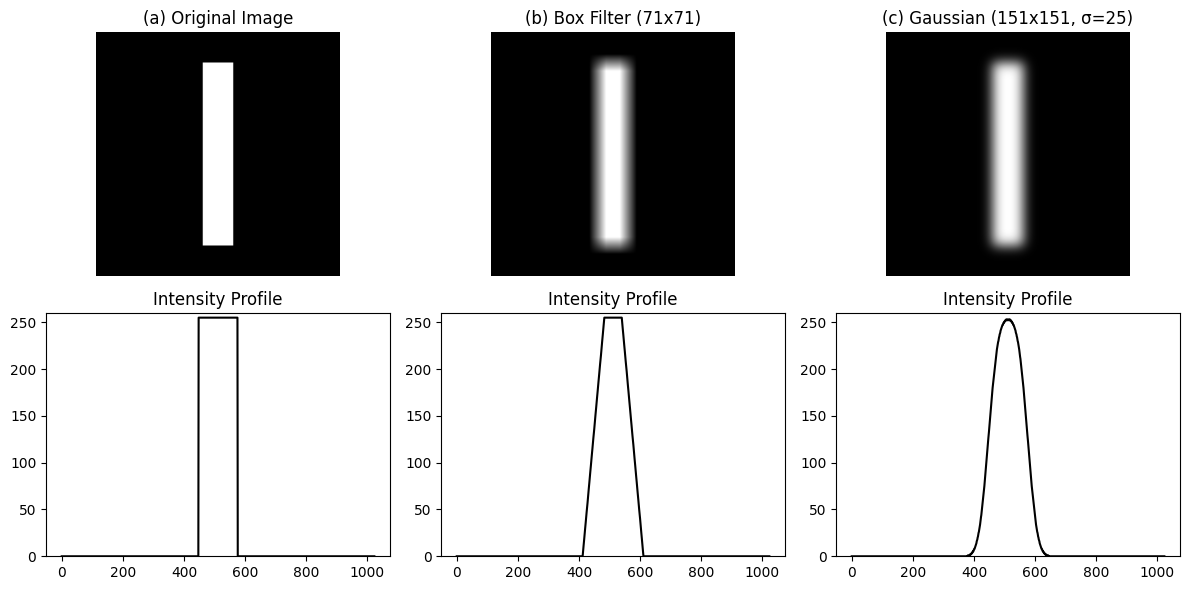

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# create black image
img = np.zeros((1024, 1024), dtype=np.uint8)

# white vertical rectangle (768 x 128)
img[128:896, 448:576] = 255

# center scan line
y = img.shape[0] // 2

# box filter (71x71)
box_kernel = np.ones((71, 71), np.float32) / (71 * 71)
box_img = cv2.filter2D(img, -1, box_kernel)

# gaussian filter (151x151, sigma=25)
gauss_img = cv2.GaussianBlur(img, (151, 151), 25)

# profiles
p_orig  = img[y, :]
p_box   = box_img[y, :]
p_gauss = gauss_img[y, :]

# -----------------------------
# display like the book
# -----------------------------
plt.figure(figsize=(12, 6))

# original
plt.subplot(2, 3, 1)
plt.title("(a) Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.plot(p_orig, color='black')
plt.title("Intensity Profile")
plt.ylim(0, 260)

# box filtered
plt.subplot(2, 3, 2)
plt.title("(b) Box Filter (71x71)")
plt.imshow(box_img, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.plot(p_box, color='black')
plt.title("Intensity Profile")
plt.ylim(0, 260)

# gaussian filtered
plt.subplot(2, 3, 3)
plt.title("(c) Gaussian (151x151, σ=25)")
plt.imshow(gauss_img, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.plot(p_gauss, color='black')
plt.title("Intensity Profile")
plt.ylim(0, 260)

plt.tight_layout()
plt.show()


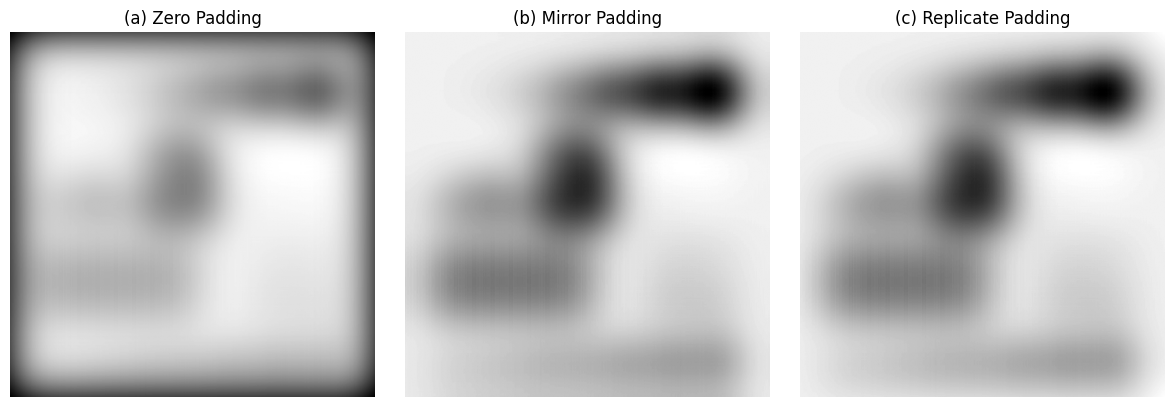

In [ ]:

img = cv2.imread('/content/Fig0333(a)(test_pattern_blurring_orig).tif', cv2.IMREAD_GRAYSCALE)

# Gaussian parameters from the book
ksize = 187
sigma = 31

# Gaussian blur with zero padding
zero_pad = cv2.GaussianBlur(
    img,
    (ksize, ksize),
    sigmaX=sigma,
    sigmaY=sigma,
    borderType=cv2.BORDER_CONSTANT
)

# Gaussian blur with mirror padding
mirror_pad = cv2.GaussianBlur(
    img,
    (ksize, ksize),
    sigmaX=sigma,
    sigmaY=sigma,
    borderType=cv2.BORDER_REFLECT
)

# Gaussian blur with replicate padding
replicate_pad = cv2.GaussianBlur(
    img,
    (ksize, ksize),
    sigmaX=sigma,
    sigmaY=sigma,
    borderType=cv2.BORDER_REPLICATE
)

# show the results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("(a) Zero Padding")
plt.imshow(zero_pad, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("(b) Mirror Padding")
plt.imshow(mirror_pad, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("(c) Replicate Padding")
plt.imshow(replicate_pad, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


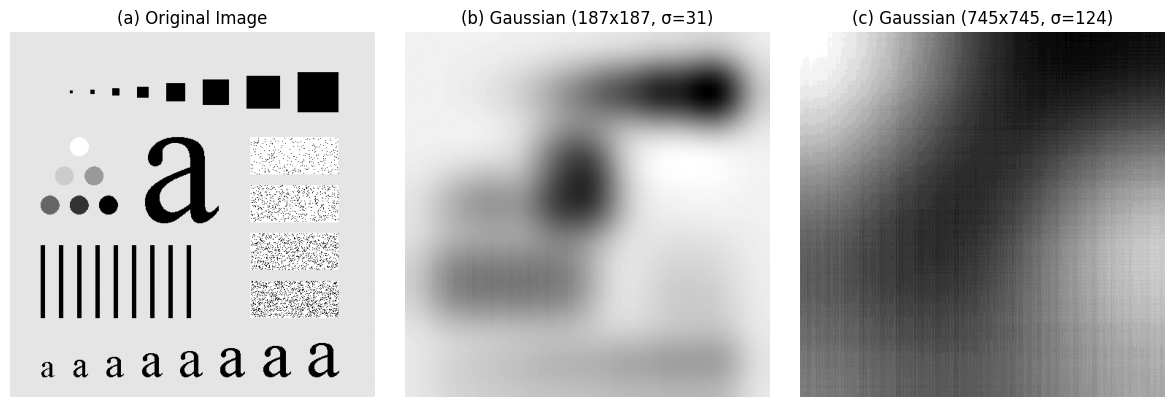

In [ ]:


# Gaussian used in Fig 3.39
gauss_187 = cv2.GaussianBlur(
    img,
    (187, 187),
    sigmaX=31,
    sigmaY=31,
    borderType=cv2.BORDER_REFLECT
)

# very large Gaussian kernel
gauss_745 = cv2.GaussianBlur(
    img,
    (745, 745),
    sigmaX=124,
    sigmaY=124,
    borderType=cv2.BORDER_REFLECT
)

# show images
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("(a) Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("(b) Gaussian (187x187, σ=31)")
plt.imshow(gauss_187, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("(c) Gaussian (745x745, σ=124)")
plt.imshow(gauss_745, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


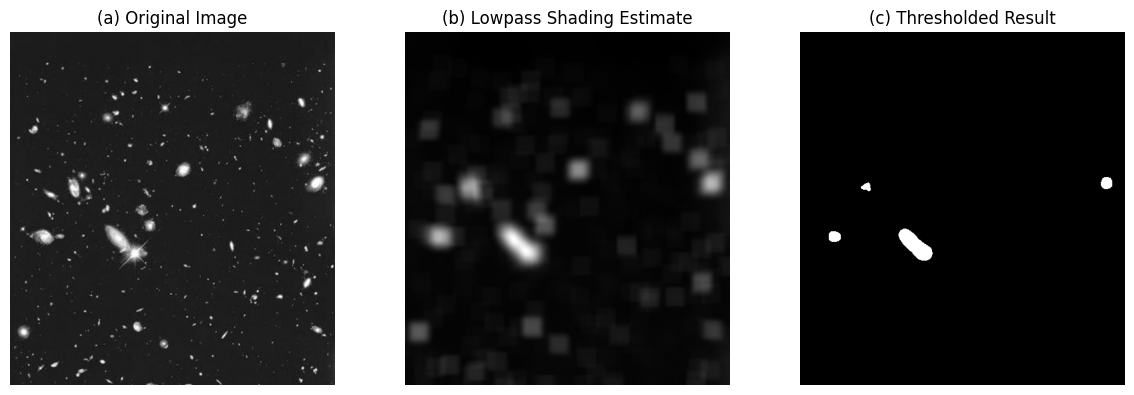

In [ ]:


img = cv2.imread('/content/Fig0334(a)(hubble-original).tif', cv2.IMREAD_GRAYSCALE)
img = img.astype(np.float32)

img = img / img.max()

# choose kernel relative to image size
h, w = img.shape
ksize = int(0.06 * w)
ksize = ksize + 1 if ksize % 2 == 0 else ksize  # make odd

# gaussian lowpass
shading = cv2.GaussianBlur(img, (ksize, ksize), sigmaX=25)

# threshold on filtered image
T = 0.4
binary = (shading >= T).astype(np.float32)

# display
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("(a) Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("(b) Lowpass Shading Estimate")
plt.imshow(shading, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("(c) Thresholded Result")
plt.imshow(binary, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

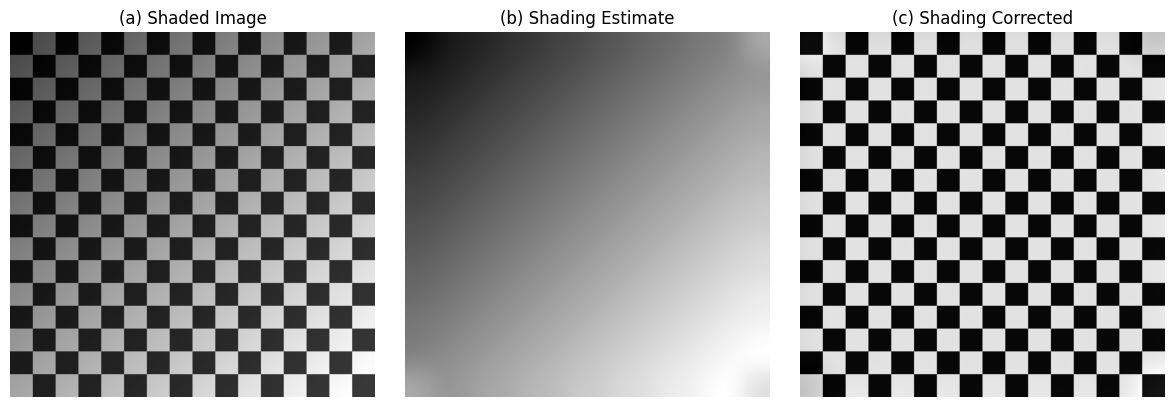

In [ ]:
# image size and square size (as in book)
N = 2048
block = 128

# create checkerboard
x, y = np.indices((N, N))
checker = ((x // block + y // block) % 2).astype(np.float32)
checker[checker == 0] = 0.3
checker[checker == 1] = 1.0

# create smooth shading in -45 degree direction
X, Y = np.meshgrid(np.linspace(0, 1, N), np.linspace(0, 1, N))
shading = 0.5 + 0.5 * (X + Y)

# shaded image (Fig 3.42a)
shaded = checker * shading
shaded = shaded / shaded.max()

# estimate shading using large Gaussian (Fig 3.42b)
shading_est = cv2.GaussianBlur(
    shaded,
    (511, 511),
    sigmaX=128,
    sigmaY=128,
    borderType=cv2.BORDER_REFLECT
)

# shading correction by division (Fig 3.42c)
corrected = shaded / (shading_est + 1e-6)
corrected = corrected / corrected.max()

# display results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("(a) Shaded Image")
plt.imshow(shaded, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("(b) Shading Estimate")
plt.imshow(shading_est, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("(c) Shading Corrected")
plt.imshow(corrected, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


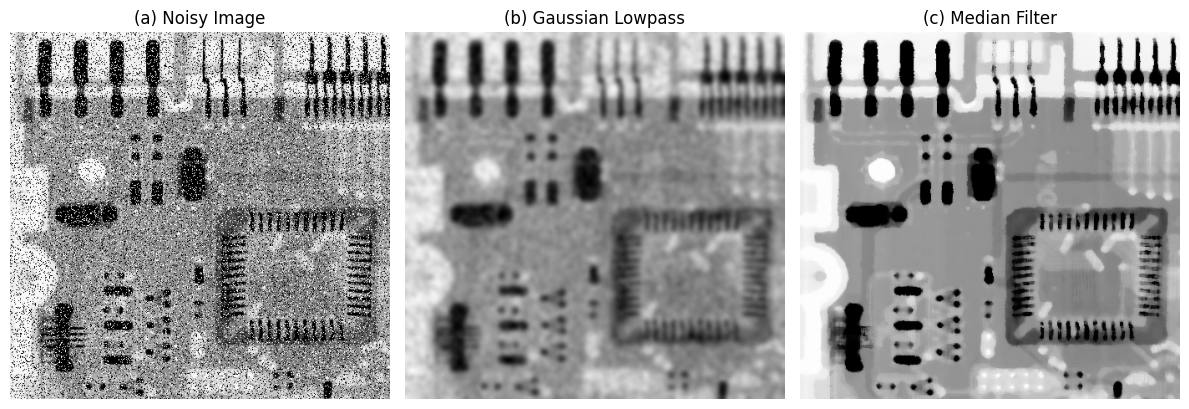

In [ ]:
# read grayscale image
img = cv2.imread("/content/Fig0335(a)(ckt_board_saltpep_prob_pt05).tif", cv2.IMREAD_GRAYSCALE)
img = img.astype(np.float32) / 255.0

# add salt and pepper noise
noisy = img.copy()
p = 0.05
rand = np.random.rand(*img.shape)

noisy[rand < p/2] = 0
noisy[rand > 1 - p/2] = 1

# gaussian lowpass filtering (19x19, sigma=3)
gaussian = cv2.GaussianBlur(
    noisy,
    (19, 19),
    sigmaX=3,
    sigmaY=3,
    borderType=cv2.BORDER_REFLECT
)

# median filtering (7x7)
median = cv2.medianBlur(
    (noisy * 255).astype(np.uint8),
    7
)
median = median.astype(np.float32) / 255.0

# show results
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("(a) Noisy Image")
plt.imshow(noisy, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("(b) Gaussian Lowpass")
plt.imshow(gaussian, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("(c) Median Filter")
plt.imshow(median, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

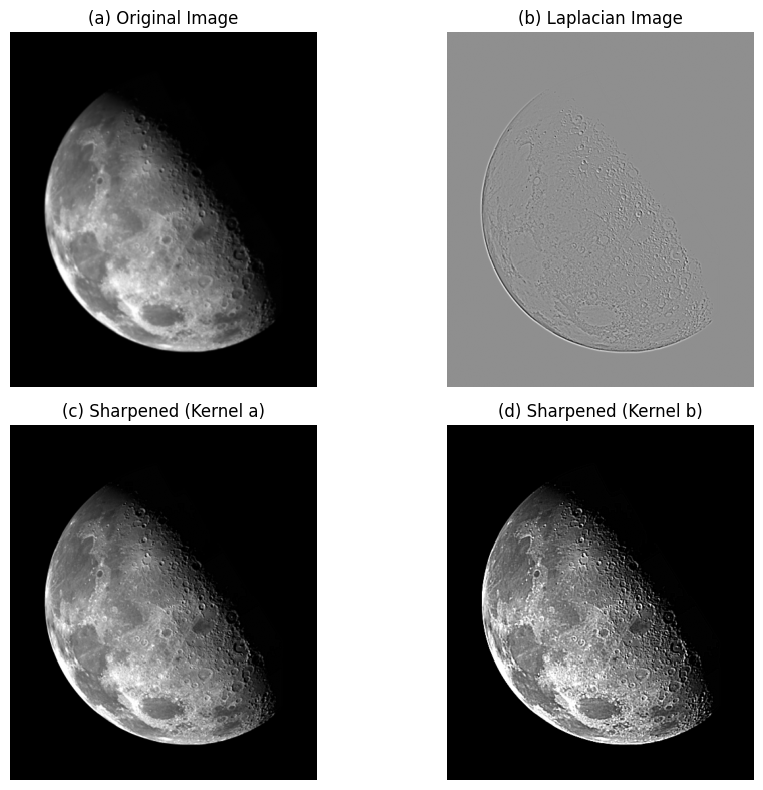

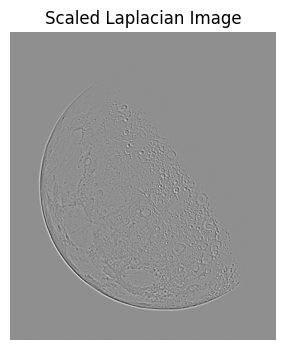

In [ ]:


# read image (grayscale)
img = cv2.imread("/content/Fig0338(a)(blurry_moon).tif", cv2.IMREAD_GRAYSCALE)
img = img.astype(np.float32)

# Laplacian kernel Fig 3.45(a)
lap1 = np.array([
    [0,  1,  0],
    [1, -4,  1],
    [0,  1,  0]
], dtype=np.float32)

# Laplacian kernel Fig 3.45(b)
lap2 = np.array([
    [1,  1,  1],
    [1, -8,  1],
    [1,  1,  1]
], dtype=np.float32)

# apply Laplacian filters
lap_img1 = cv2.filter2D(img, -1, lap1)
lap_img2 = cv2.filter2D(img, -1, lap2)

# sharpen using Eq (3-54), c = -1
sharp1 = img - lap_img1
sharp2 = img - lap_img2

# scale Laplacian for display (Fig 3.47)
lap_scaled = lap_img1 - lap_img1.min()
lap_scaled = lap_scaled / lap_scaled.max() * 255

# clip sharpened images
sharp1 = np.clip(sharp1, 0, 255)
sharp2 = np.clip(sharp2, 0, 255)

# show results
plt.figure(figsize=(10, 8))

plt.subplot(2,2,1)
plt.title("(a) Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(2,2,2)
plt.title("(b) Laplacian Image")
plt.imshow(lap_img1, cmap='gray')
plt.axis('off')

plt.subplot(2,2,3)
plt.title("(c) Sharpened (Kernel a)")
plt.imshow(sharp1, cmap='gray')
plt.axis('off')

plt.subplot(2,2,4)
plt.title("(d) Sharpened (Kernel b)")
plt.imshow(sharp2, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

# show scaled Laplacian (Fig 3.47)
plt.figure(figsize=(4,4))
plt.title("Scaled Laplacian Image")
plt.imshow(lap_scaled, cmap='gray')
plt.axis('off')
plt.show()


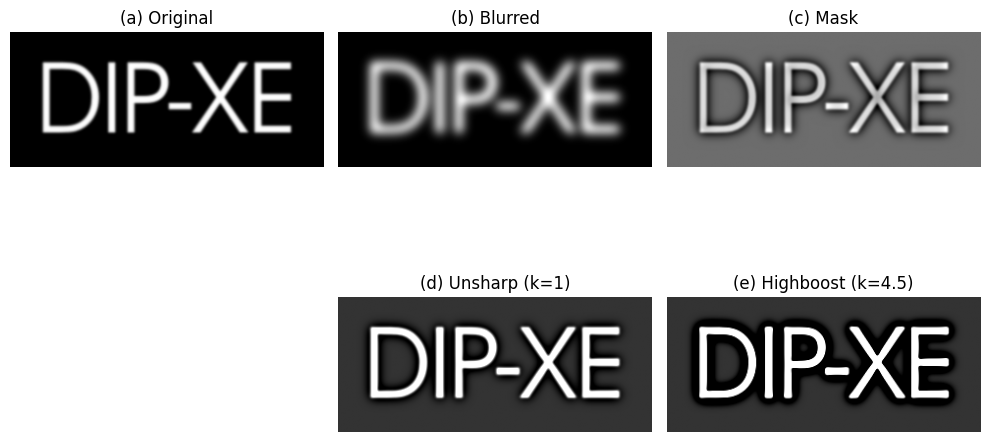

In [ ]:

# read grayscale image
img = cv2.imread("/content/Fig0340(a)(dipxe_text).tif", cv2.IMREAD_GRAYSCALE)
img = img.astype(np.float32)

# gaussian blur (31x31, sigma=5)
blur = cv2.GaussianBlur(
    img,
    (31, 31),
    sigmaX=5,
    sigmaY=5,
    borderType=cv2.BORDER_REFLECT
)

# unsharp mask
mask = img - blur

# unsharp masking (k = 1)
unsharp = img + 1 * mask

# highboost filtering (k = 4.5)
highboost = img + 4.5 * mask

# clip for display
unsharp = np.clip(unsharp, 0, 255)
highboost = np.clip(highboost, 0, 255)

# show results
plt.figure(figsize=(10, 6))

plt.subplot(2,3,1)
plt.title("(a) Original")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(2,3,2)
plt.title("(b) Blurred")
plt.imshow(blur, cmap='gray')
plt.axis('off')

plt.subplot(2,3,3)
plt.title("(c) Mask")
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.subplot(2,3,5)
plt.title("(d) Unsharp (k=1)")
plt.imshow(unsharp, cmap='gray')
plt.axis('off')

plt.subplot(2,3,6)
plt.title("(e) Highboost (k=4.5)")
plt.imshow(highboost, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


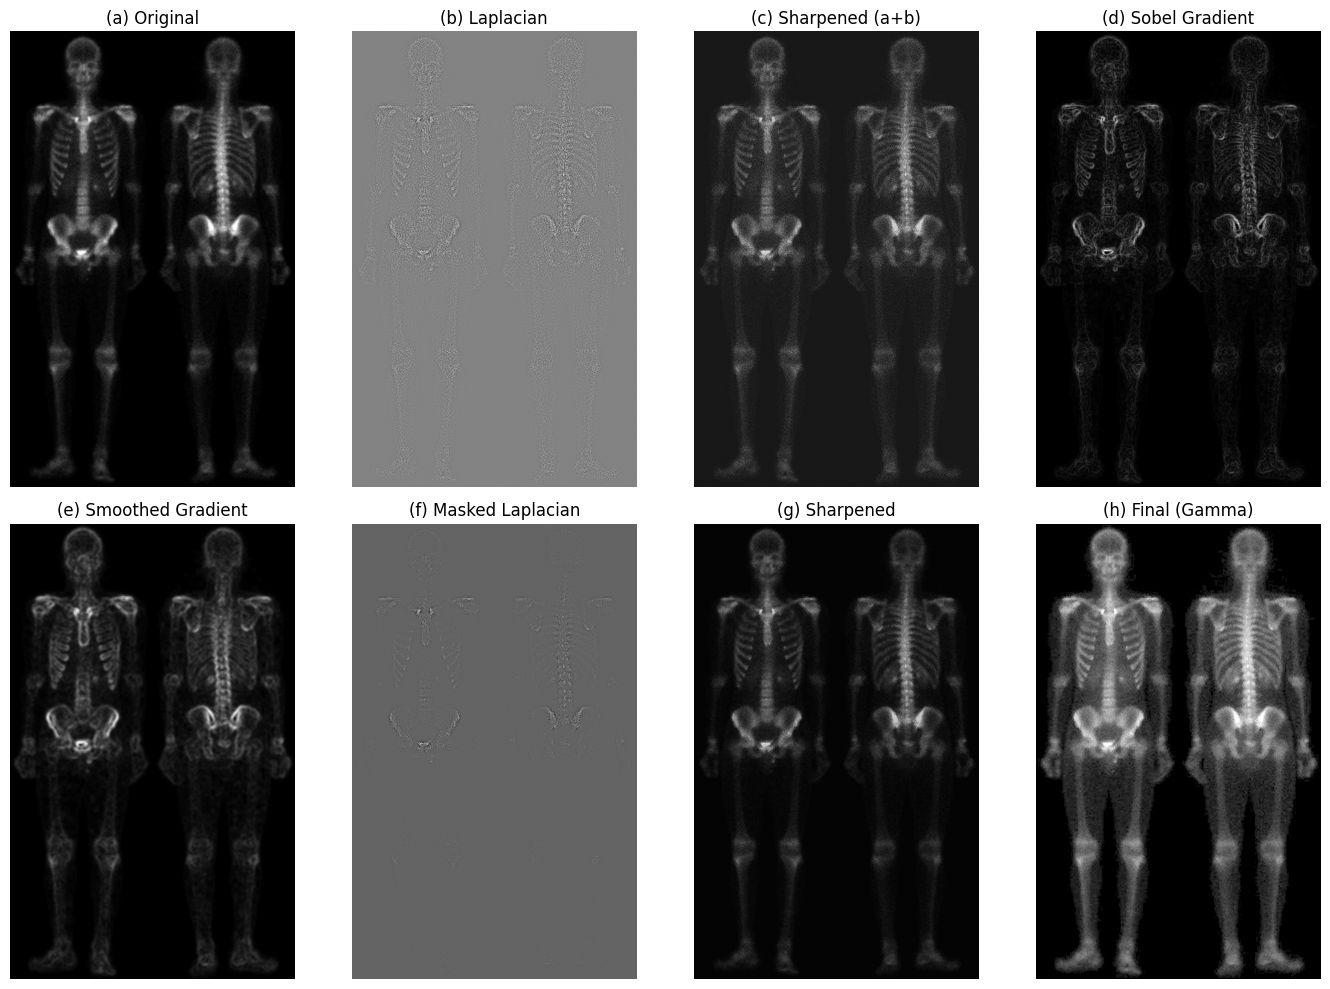

In [ ]:

# load original image (grayscale)
img = cv2.imread("/content/Fig0343(a)(skeleton_orig).tif", cv2.IMREAD_GRAYSCALE)
img = img.astype(np.float32) / 255.0


# Laplacian kernel (Fig 3.45(d))
lap_kernel = np.array([[0, -1, 0],
                        [-1, 4, -1],
                        [0, -1, 0]], dtype=np.float32)

lap = cv2.filter2D(img, -1, lap_kernel)

# sharpened using Laplacian
sharp_lap = img + lap

# Sobel gradient
gx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)
gy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)
grad = np.sqrt(gx**2 + gy**2)

# smooth gradient with 5x5 box filter
grad_smooth = cv2.blur(grad, (5,5))

# masked Laplacian
masked_lap = lap * grad_smooth

# sharpened using masked Laplacian
sharp_masked = img + masked_lap

# power-law (gamma) transform
gamma = 0.5
final = np.power(np.clip(sharp_masked, 0, 1), gamma)

# display
titles = [
    "(a) Original",
    "(b) Laplacian",
    "(c) Sharpened (a+b)",
    "(d) Sobel Gradient",
    "(e) Smoothed Gradient",
    "(f) Masked Laplacian",
    "(g) Sharpened",
    "(h) Final (Gamma)"
]

images = [
    img,
    lap + 0.5,
    sharp_lap,
    grad,
    grad_smooth,
    masked_lap + 0.5,
    sharp_masked,
    final
]

plt.figure(figsize=(14,10))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()
